In [ ]:
import os
import pickle
import sys

import torch

root_dir = os.path.abspath("..")
package_dir = os.path.abspath(os.path.join(root_dir, "current_setpoints"))
optimization_dir = os.path.abspath(os.path.join(package_dir, "optimization"))
model_dir = os.path.abspath(os.path.join(package_dir, "model"))
data_dir = os.path.join(root_dir, "data")

os.makedirs(data_dir, exist_ok=True)

for path in [root_dir, package_dir, optimization_dir, model_dir]:
    if path not in sys.path:
        sys.path.append(path)

from current_setpoints.optimization import (
    ModelNeural,
    MotorOptimizer,
    calculate_grid,
    get_correction_grid,
    grid_to_data,
)
from current_setpoints.utils.neural import load_neural_model
from current_setpoints.utils.plotting import plot_grid_segments


Loading trained NeuralTorquePredictor...
Loading existing correction grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEETIE_machine2_correction.pkl'...
Plotting Correction Grid (Neural Predicted Torques)...


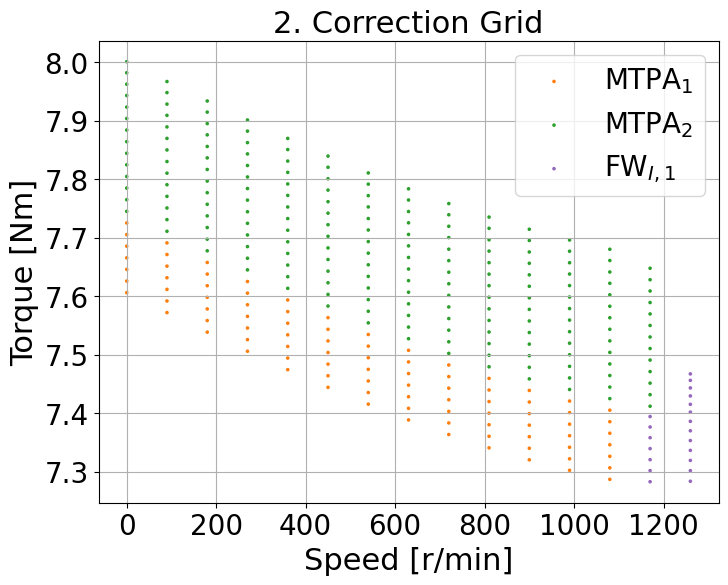

In [4]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights_dir = os.path.join(root_dir, "weights")
MODEL_SAVE_PATH = os.path.join(weights_dir, "NTM_Best_Model.pth")
SCALER_SAVE_PATH = os.path.join(weights_dir, "NTM_Best_Scaler.npy")
INPUT_SIZE = 5
OPTIMAL_HIDDEN_SIZE = 16

print("\nLoading trained NeuralTorquePredictor...")
neural_net, scaler = load_neural_model(
    weights_path=MODEL_SAVE_PATH,
    scaler_path=SCALER_SAVE_PATH,
    hidden_size=OPTIMAL_HIDDEN_SIZE,
    input_size=INPUT_SIZE,
    machine=machine,
    device=DEVICE
)

neural_model_wrapper = ModelNeural(
    machine=machine,
    neural_model=neural_net,
    scaler=scaler,
    device=DEVICE
)

solver_opts_neural = {"disp": False, "ftol": 1e-5, "maxiter": 2500, "eps": 1e-4}
neural_optimizer = MotorOptimizer(model=neural_model_wrapper, opts=solver_opts_neural)
corr_filename = os.path.join(data_dir, "IEETIE_machine2_correction.pkl")

if os.path.isfile(corr_filename):
    print(f"Loading existing correction grid from '{corr_filename}'...")
    with open(corr_filename, "rb") as file:
        correction_grid_result = pickle.load(file)
else:
    print("Starting Correction Grid calculation...")
    correction_grid_result = get_correction_grid(
        dict_grid=grid_result,
        neural_model=neural_net,
        scaler=scaler,
        device=DEVICE,
        machine=machine
    )
    with open(corr_filename, "wb") as file:
        pickle.dump(correction_grid_result, file)
    print(f"Correction Grid successfully calculated and saved to '{corr_filename}'")

print("Plotting Correction Grid (Neural Predicted Torques)...")
correction_machine_data = grid_to_data(correction_grid_result, k_skip=1)
plot_grid_segments(
    correction_machine_data,
    title="2. Correction Grid",
    override_torq_2d=correction_grid_result["grid_torq_neural"]
)

Loading existing recalculated grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEETIE_machine2_recalculated.pkl'...
Plotting Recalculated Grid...


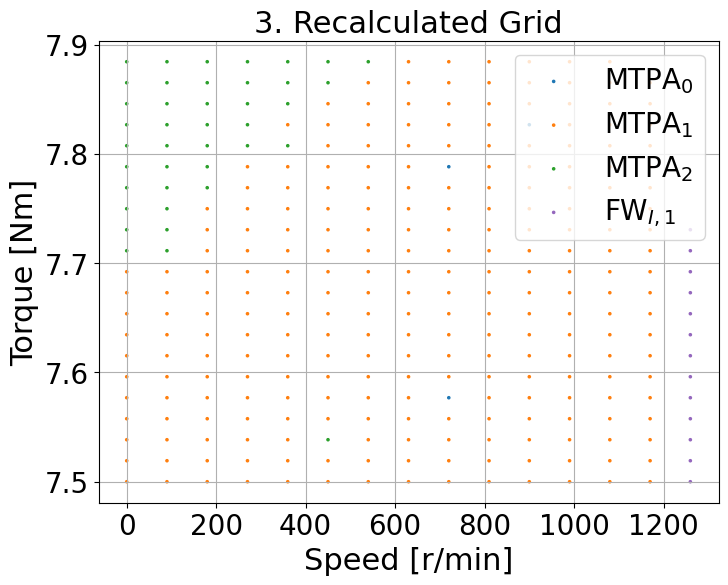

In [5]:
recalc_filename = os.path.join(data_dir, "IEETIE_machine2_recalculated.pkl")

if os.path.isfile(recalc_filename):
    print(f"Loading existing recalculated grid from '{recalc_filename}'...")
    with open(recalc_filename, "rb") as file:
        recalc_grid_result = pickle.load(file)
else:
    print("Starting Recalculated Grid calculation. Using baseline currents as warm starts...")
    recalc_grid_result = calculate_grid(
        optimizer=neural_optimizer,
        transform=transform,
        opts=grid_opts,
        mode="recalculated",
        dict_grid_corr=correction_grid_result
    )
    with open(recalc_filename, "wb") as file:
        pickle.dump(recalc_grid_result, file)
    print(f"Recalculated Grid successfully calculated and saved to '{recalc_filename}'")

print("Plotting Recalculated Grid...")
recalc_machine_data = grid_to_data(recalc_grid_result, k_skip=1)
plot_grid_segments(recalc_machine_data, title="3. Recalculated Grid")

Loading existing compensated neural grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEETIE_machine2_compensated.pkl'...
Plotting Compensated Neural Grid...


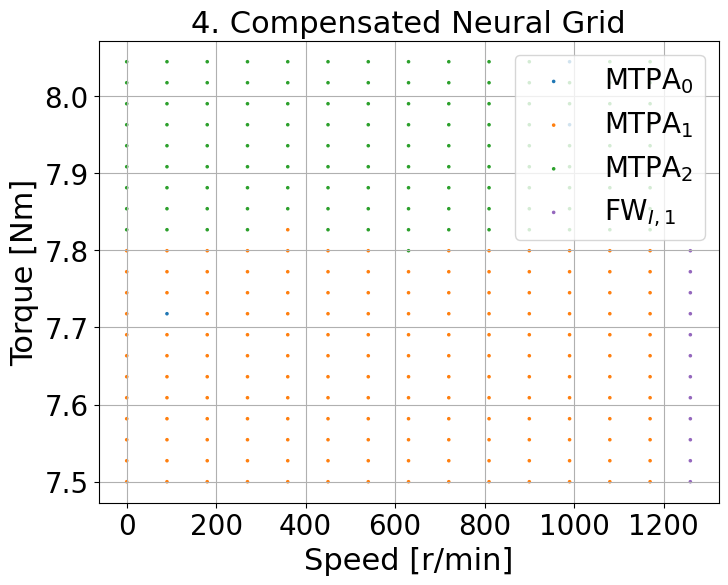

In [6]:
neural_filename = os.path.join(data_dir, "IEETIE_machine2_compensated.pkl")

if os.path.isfile(neural_filename):
    print(f"Loading existing compensated neural grid from '{neural_filename}'...")
    with open(neural_filename, "rb") as file:
        neural_grid_result = pickle.load(file)
else:
    print("Starting Compensated Neural Grid calculation. This may take longer due to network inference...")
    neural_grid_result = calculate_grid(
        optimizer=neural_optimizer,
        transform=transform,
        opts=grid_opts,
        mode="standard"
    )
    with open(neural_filename, "wb") as file:
        pickle.dump(neural_grid_result, file)
    print(f"Compensated Neural Grid successfully calculated and saved to '{neural_filename}'")

print("Plotting Compensated Neural Grid...")
neural_machine_data = grid_to_data(neural_grid_result, k_skip=1)
plot_grid_segments(neural_machine_data, title="4. Compensated Neural Grid")